# Smart Supply Chain - Exploratory Data Analysis & Preprocessing

This notebook explores the **DataCo Smart Supply Chain Dataset** to understand customer segments, sales trends, fraud signals, and shipping performance, and demonstrates the preprocessing steps for machine learning using **Matplotlib** and **Seaborn**.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Set Seaborn theme and styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Loading the Data
We load a subset of the dataset for exploration. Accent characters require loading with `latin-1` encoding.

In [3]:
# Load 50,000 rows for fast exploratory analysis
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin-1', nrows=50000)
print(f"Dataset shape: {df.shape}")

Dataset shape: (50000, 53)


## 2. Basic Dataset Profiling
Let's look at the top columns, data types, and check for missing values.

In [4]:
# Display column information and missing values
info_df = pd.DataFrame({
    'DataType': df.dtypes,
    'MissingValues': df.isnull().sum(),
    'UniqueValues': df.nunique()
})
print("Top columns with missing values:")
print(info_df[info_df['MissingValues'] > 0].sort_values('MissingValues', ascending=False))

Top columns with missing values:
                    DataType  MissingValues  UniqueValues
Product Description  float64          50000             0
Order Zipcode        float64          43427           517
Customer Zipcode     float64              2           995
Customer Lname           str              1          1089


## 3. Shipping Performance & Delay Analysis
Let's check the shipping performance. We calculate `delay_delta` as the difference between the real shipping days and the scheduled shipping days.

Shipping Delay Statistics (in days):
count    50000.000000
mean         0.634240
std          1.473914
min         -2.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          4.000000
Name: delay_delta, dtype: float64


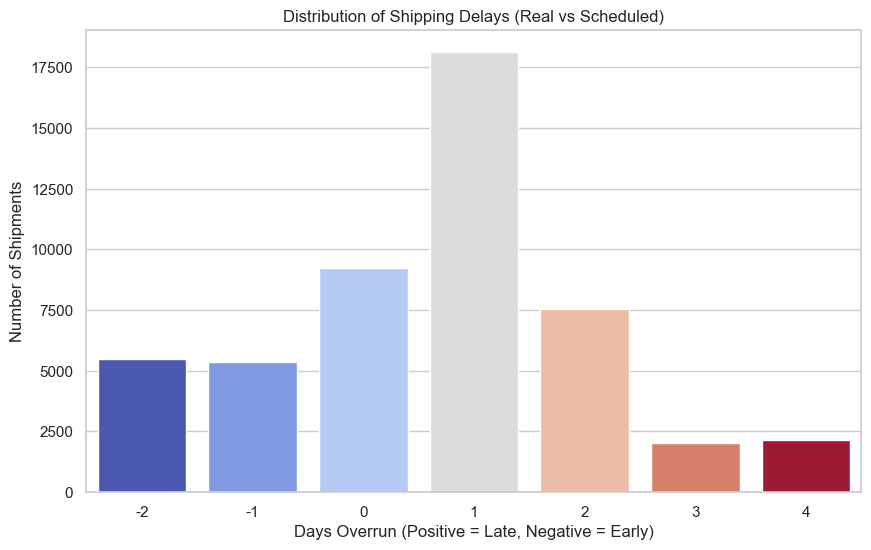

In [5]:
# Calculate delay delta
df['delay_delta'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

print("Shipping Delay Statistics (in days):")
print(df['delay_delta'].describe())

# Plot the distribution of delays using Seaborn countplot
sns.countplot(data=df, x='delay_delta', hue='delay_delta', palette='coolwarm', legend=False)
plt.title('Distribution of Shipping Delays (Real vs Scheduled)')
plt.xlabel('Days Overrun (Positive = Late, Negative = Early)')
plt.ylabel('Number of Shipments')
plt.show()

## 4. Fraud and Order Status Analysis
Let's check the distribution of order statuses, specifically identifying labeled fraud cases (`SUSPECTED_FRAUD`).

Order Status Distribution:
Order Status
COMPLETE           19326
PENDING_PAYMENT    11173
CLOSED              9138
ON_HOLD             3136
PROCESSING          3041
PENDING             2592
PAYMENT_REVIEW       553
SUSPECTED_FRAUD      550
CANCELED             491
Name: count, dtype: int64


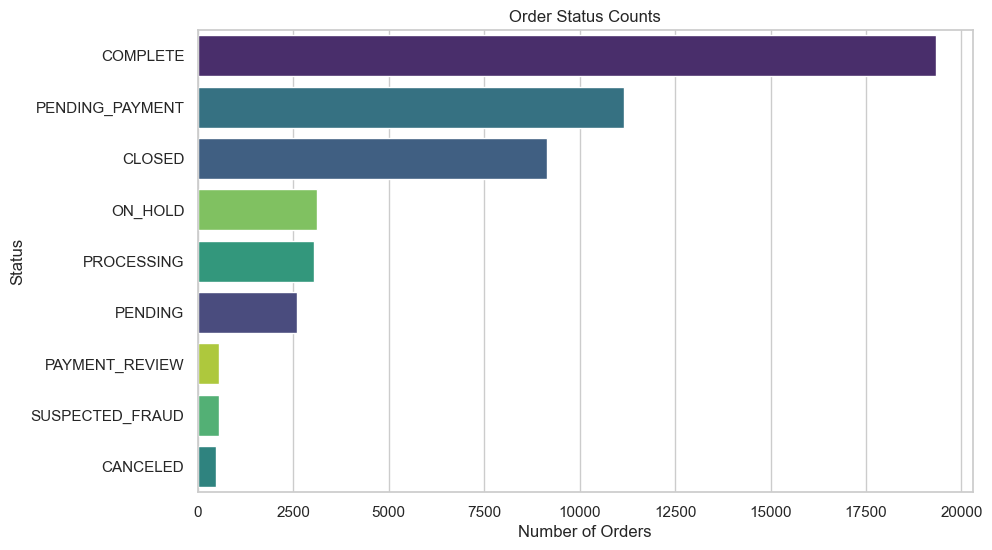

In [6]:
# Distribution of order status
print("Order Status Distribution:")
status_counts = df['Order Status'].value_counts()
print(status_counts)

# Visualizing using a horizontal Seaborn countplot
sns.countplot(data=df, y='Order Status', order=status_counts.index, hue='Order Status', palette='viridis', legend=False)
plt.title('Order Status Counts')
plt.xlabel('Number of Orders')
plt.ylabel('Status')
plt.show()

## 5. Customer Value Segmentation (RFM Analysis)
We calculate Recency, Frequency, and Monetary (RFM) values for each customer. This helps us group customers for segmentation.

RFM Statistics:
            Recency     Frequency      Monetary
count  12691.000000  12691.000000  12691.000000
mean     367.999685      2.120637    773.584952
std      288.753561      1.427643    684.683060
min        0.000000      1.000000      9.990000
25%      127.000000      1.000000    260.649994
50%      294.000000      2.000000    532.580017
75%      551.000000      3.000000   1129.920021
max     1126.000000     11.000000   5831.490068


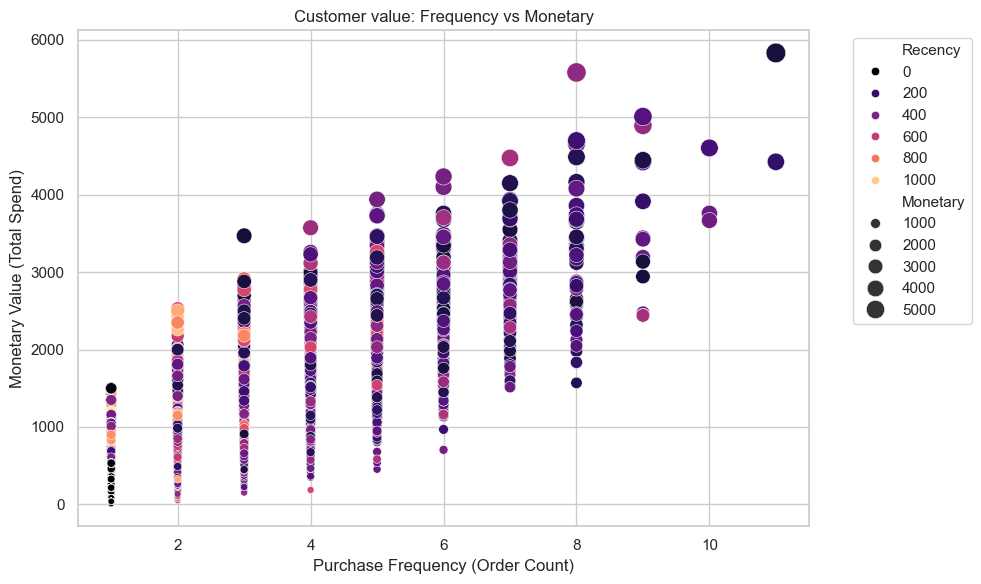

In [7]:
# Parse order dates
df['order_date_parsed'] = pd.to_datetime(df['order date (DateOrders)'])
snapshot_date = df['order_date_parsed'].max()

# Aggregate per customer
rfm = df.groupby('Customer Id').agg({
    'order_date_parsed': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Order Id': 'nunique',                                           # Frequency
    'Sales': 'sum'                                                   # Monetary
}).reset_index()

rfm.rename(columns={
    'order_date_parsed': 'Recency',
    'Order Id': 'Frequency',
    'Sales': 'Monetary'
}, inplace=True)

print("RFM Statistics:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

# Plotting Customer Monetary vs Frequency with Seaborn scatterplot
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Recency', size='Monetary', sizes=(20, 200), palette='magma')
plt.title('Customer value: Frequency vs Monetary')
plt.xlabel('Purchase Frequency (Order Count)')
plt.ylabel('Monetary Value (Total Spend)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 6. Feature Normalization & Scaling Demonstration
Now we demonstrate how the raw features are prepared, outlier-cleaned, and scaled using `StandardScaler` for the anomaly detection model.

In [8]:
# 1. Clean outliers
cleaned_df = df[
    (df["Product Price"] > 0) & 
    (df["Sales"] >= 0) & 
    (df["Order Item Quantity"] > 0)
].copy()

# Engineer features
cleaned_df['delay_delta'] = cleaned_df['Days for shipping (real)'] - cleaned_df['Days for shipment (scheduled)']
cleaned_df['profit_margin'] = cleaned_df['Order Profit Per Order'] / cleaned_df['Sales'].replace(0, np.nan)
cleaned_df['profit_margin'] = cleaned_df['profit_margin'].fillna(0)
cleaned_df['discount_ratio'] = cleaned_df['Order Item Discount Rate']
cleaned_df['is_fraud'] = (cleaned_df['Order Status'] == 'SUSPECTED_FRAUD').astype(int)

# 2. Select numerical features for Anomaly Model
anomaly_cols = ['delay_delta', 'Order Item Quantity', 'Sales', 'profit_margin', 'discount_ratio']
X_raw = cleaned_df[anomaly_cols].fillna(0)

print("=== RAW FEATURES ===")
print(X_raw.head())

# 3. Scale Features using StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=anomaly_cols)

print("\n=== SCALED FEATURES (Mean = 0, Std = 1) ===")
print(X_scaled.head())
print("\nVerification - Means:")
print(X_scaled.mean().round(4))
print("Verification - Stds:")
print(X_scaled.std().round(4))

=== RAW FEATURES ===
   delay_delta  Order Item Quantity   Sales  profit_margin  discount_ratio
0           -1                    1  327.75       0.278413            0.04
1            1                    1  327.75      -0.760000            0.05
2            0                    1  327.75      -0.756003            0.06
3           -1                    1  327.75       0.069748            0.07
4           -2                    1  327.75       0.409489            0.09

=== SCALED FEATURES (Mean = 0, Std = 1) ===
   delay_delta  Order Item Quantity     Sales  profit_margin  discount_ratio
0    -1.108787            -0.863956  0.939141       0.403057       -0.877513
1     0.248158            -0.863956  0.939141      -2.073307       -0.735730
2    -0.430314            -0.863956  0.939141      -2.063775       -0.593947
3    -1.108787            -0.863956  0.939141      -0.094559       -0.452163
4    -1.787259            -0.863956  0.939141       0.715640       -0.168597

Verification - Means:

## 7. Normalization
Let's compare three states of the features:
1. **Raw Features:** 'Sales' completely dominates the scale, making other variables look like zero.
2. **Standardized Features (StandardScaler):** Centers around 0 and uses Standard Deviations. Outliers remain clearly visible (e.g. Sales has values > 10) without squishing the boxes of the other features.
3. **Normalized Features (MinMaxScaler):** Forces all data strictly between 0 and 1. Notice how the extreme outlier in 'Sales' (value near 1.0) squishes the normal Sales boxes flat at the bottom, destroying the variance detail.

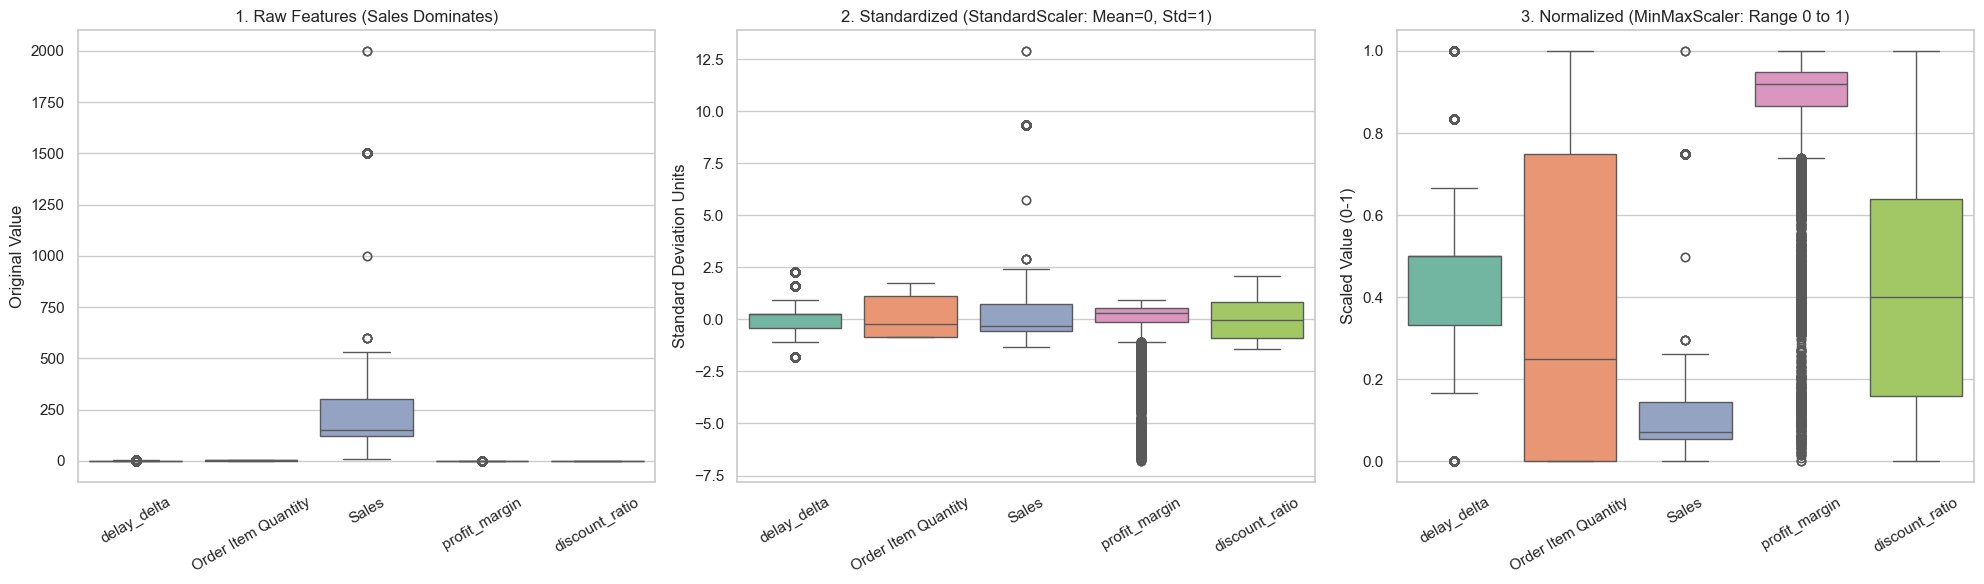

In [9]:

normalizer = MinMaxScaler()
X_normalized = pd.DataFrame(normalizer.fit_transform(X_raw), columns=anomaly_cols)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(data=X_raw, ax=axes[0], palette='Set2')
axes[0].set_title('1. Raw Features (Sales Dominates)')
axes[0].set_ylabel('Original Value')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=X_scaled, ax=axes[1], palette='Set2')
axes[1].set_title('2. Standardized (StandardScaler: Mean=0, Std=1)')
axes[1].set_ylabel('Standard Deviation Units')
axes[1].tick_params(axis='x', rotation=30)

sns.boxplot(data=X_normalized, ax=axes[2], palette='Set2')
axes[2].set_title('3. Normalized (MinMaxScaler: Range 0 to 1)')
axes[2].set_ylabel('Scaled Value (0-1)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
df["Product Name"].unique().shape[0]

98